In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib as jb

In [2]:
import sys

!{sys.executable} -m pip install openpyxl

You should consider upgrading via the 'c:\Users\srikh\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


In [3]:
base_directory = os.path.dirname(os.getcwd())
print(base_directory)

dataset_path = os.path.join(base_directory, 'farming ml datasets', 'crop_yield_prediction.xlsx')
print(dataset_path)

dataset = pd.read_excel(dataset_path)

d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System
d:\ML PROJECTS\AgroAqua AI Intelligent Farming and Aquaculture Management System\farming ml datasets\crop_yield_prediction.xlsx


In [4]:
dataset

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
0,1230.0,80.0,28,80.0,24.0,20.0,12.0
1,480.0,60.0,36,70.0,20.0,18.0,8.0
2,1250.0,75.0,29,78.0,22.0,19.0,11.0
3,450.0,65.0,35,70.0,19.0,18.0,9.0
4,1200.0,80.0,27,79.0,22.0,19.0,11.0
...,...,...,...,...,...,...,...
104,NaN,NaN,NaN,NaN,NaN,NaN,NaN
105,NaN,NaN,NaN,NaN,NaN,NaN,NaN
106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
dataset = dataset.dropna()

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 99 entries, 0 to 98
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Rain Fall (mm)  99 non-null     float64
 1   Fertilizer      99 non-null     float64
 2   Temperatue      99 non-null     object 
 3   Nitrogen (N)    99 non-null     float64
 4   Phosphorus (P)  99 non-null     float64
 5   Potassium (K)   99 non-null     float64
 6   Yeild (Q/acre)  99 non-null     float64
dtypes: float64(6), object(1)
memory usage: 6.2+ KB


In [7]:
print(pd.isnull(dataset).sum())

Rain Fall (mm)    0
Fertilizer        0
Temperatue        0
Nitrogen (N)      0
Phosphorus (P)    0
Potassium (K)     0
Yeild (Q/acre)    0
dtype: int64


In [8]:
dataset.describe()

,Rain Fall (mm),Fertilizer,Nitrogen (N),Phosphorus (P),Potassium (K),Yeild (Q/acre)
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,849.797980,67.808081,70.737374,21.131313,18.060606,9.050505
std,400.042676,10.028202,6.677079,1.951695,1.817254,1.965902
min,400.000000,50.000000,59.000000,18.000000,15.000000,5.500000
25%,450.000000,60.000000,65.000000,19.500000,16.000000,7.000000
50%,1150.000000,70.000000,71.000000,21.000000,19.000000,9.000000
75%,1237.500000,77.000000,77.000000,23.000000,19.000000,11.000000
max,1300.000000,80.000000,80.000000,25.000000,22.000000,12.000000


In [9]:
duplicates = dataset.duplicated().sum()
print(f'The number of duplicates is {duplicates}')

The number of duplicates is 4


In [10]:
dataset_shape = dataset.shape
print(f'The dataset shape is {dataset_shape}')

The dataset shape is (99, 7)


In [11]:
dataset_object_type = dataset.dtypes
print(dataset_object_type)

Rain Fall (mm)    float64
Fertilizer        float64
Temperatue         object
Nitrogen (N)      float64
Phosphorus (P)    float64
Potassium (K)     float64
Yeild (Q/acre)    float64
dtype: object


In [12]:
numeric_columns =  dataset.select_dtypes(include='number').columns
print(numeric_columns)

Index(['Rain Fall (mm)', 'Fertilizer', 'Nitrogen (N)', 'Phosphorus (P)',
       'Potassium (K)', 'Yeild (Q/acre)'],
      dtype='object')


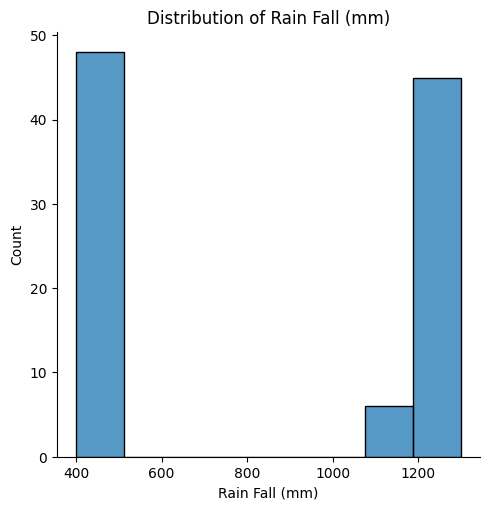

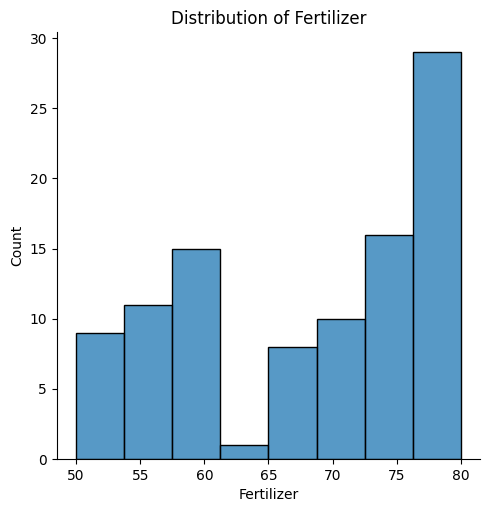

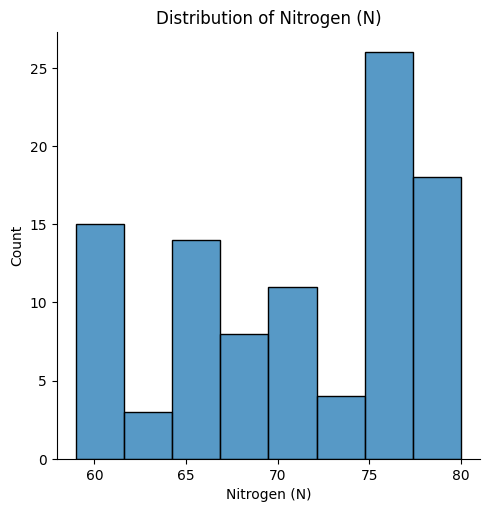

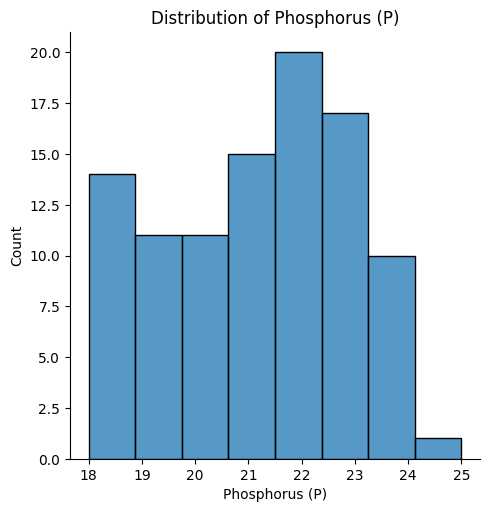

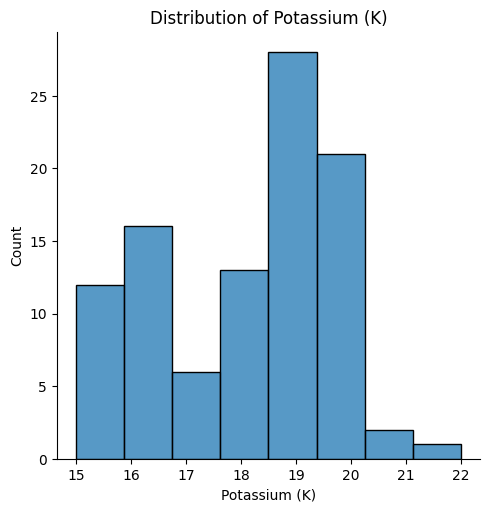

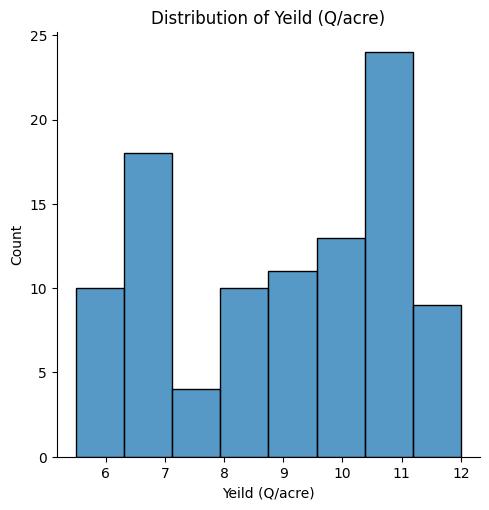

In [13]:
for col in numeric_columns:
    plt.Figure(figsize=(10,10))
    sns.displot(dataset[col])
    plt.title(f'Distribution of {col}')
    plt.show()

In [14]:
categorical_columns = dataset.select_dtypes(include='object').columns
print(categorical_columns)

Index(['Temperatue'], dtype='object')


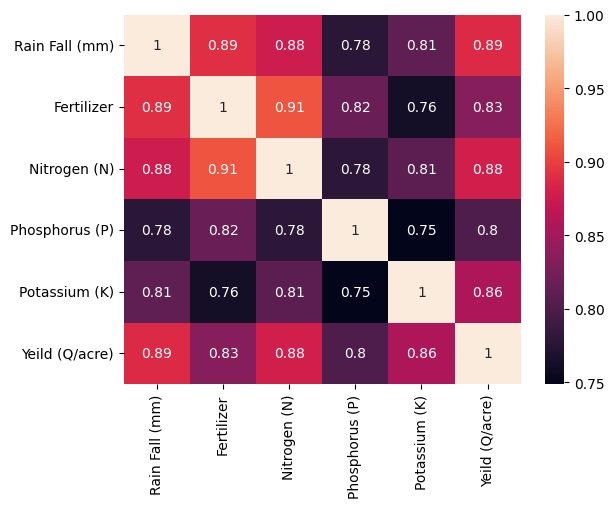

In [15]:
sns.heatmap(dataset[numeric_columns].corr(), annot=True)
plt.show()

In [16]:
x = dataset.drop('Yeild (Q/acre)', axis=1)

In [17]:
x

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K)
0,1230.0,80.0,28,80.0,24.0,20.0
1,480.0,60.0,36,70.0,20.0,18.0
2,1250.0,75.0,29,78.0,22.0,19.0
3,450.0,65.0,35,70.0,19.0,18.0
4,1200.0,80.0,27,79.0,22.0,19.0
...,...,...,...,...,...,...
94,1250.0,77.0,28,78.0,23.0,20.0
95,425.0,60.0,39,65.0,19.0,17.0
96,1220.0,79.0,28,77.0,23.0,21.0
97,480.0,65.0,36,68.0,21.0,16.0


In [18]:
y = dataset['Yeild (Q/acre)']

In [19]:
y

0     12.0
1      8.0
2     11.0
3      9.0
4     11.0
      ... 
94     9.0
95     6.5
96    10.5
97     7.0
98    12.0
Name: Yeild (Q/acre), Length: 99, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [21]:
x_train

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K)
49,450.0,50.0,37,60.0,18.0,15.0
70,1245.0,77.0,27,75.0,22.0,20.0
68,1225.0,75.0,29,77.0,23.0,19.0
15,400.0,60.0,39,60.0,18.0,15.0
39,440.0,58.0,37,66.0,22.0,18.0
...,...,...,...,...,...,...
60,1175.0,77.0,25,75.0,22.0,19.0
71,450.0,59.0,40,67.0,18.0,16.0
14,1250.0,70.0,24,70.0,22.0,18.0
92,1150.0,78.0,29,77.0,21.0,18.0


In [22]:
x_test

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K)
62,1200.0,75.0,27,79.0,21.0,20.0
40,1275.0,78.0,28,77.0,23.0,21.0
95,425.0,60.0,39,65.0,19.0,17.0
18,1150.0,77.0,28,76.0,23.0,20.0
97,480.0,65.0,36,68.0,21.0,16.0
84,1300.0,76.0,28,77.0,22.0,20.0
64,1200.0,75.0,27,76.0,21.0,19.0
42,1175.0,78.0,28,75.0,23.0,22.0
10,1280.0,80.0,26,80.0,24.0,20.0
0,1230.0,80.0,28,80.0,24.0,20.0


In [23]:
y_train

49     6.0
70     9.5
68    10.0
15     5.5
39     8.0
      ... 
60    11.0
71     7.5
14    11.0
92     9.0
51     6.0
Name: Yeild (Q/acre), Length: 79, dtype: float64

In [24]:
y_test

62    11.0
40    11.0
95     6.5
18    11.0
97     7.0
84     9.0
64    11.0
42    11.0
10    12.0
0     12.0
31     6.0
76    12.0
47     8.0
26     6.0
44    11.0
4     11.0
22     7.0
12    11.0
88    11.0
73     7.0
Name: Yeild (Q/acre), dtype: float64

In [25]:
# from sklearn.compose import ColumnTransformer
# from sklearn.preprocessing import OneHotEncoder

# ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), categorical_columns)], remainder='passthrough')
# x_train = ct.fit_transform(x_train)
# x_test = ct.transform(x_test)
# print("Onehot encode done!")

In [26]:
x_train

,Rain Fall (mm),Fertilizer,Temperatue,Nitrogen (N),Phosphorus (P),Potassium (K)
49,450.0,50.0,37,60.0,18.0,15.0
70,1245.0,77.0,27,75.0,22.0,20.0
68,1225.0,75.0,29,77.0,23.0,19.0
15,400.0,60.0,39,60.0,18.0,15.0
39,440.0,58.0,37,66.0,22.0,18.0
...,...,...,...,...,...,...
60,1175.0,77.0,25,75.0,22.0,19.0
71,450.0,59.0,40,67.0,18.0,16.0
14,1250.0,70.0,24,70.0,22.0,18.0
92,1150.0,78.0,29,77.0,21.0,18.0


In [27]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler(with_mean=False)

x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

In [28]:
x_train

array([[ 1.12773249,  5.01687725,  6.79506567,  9.23880072,  9.3150322 ,
         8.5007961 ],
       [ 3.12005989,  7.72599097,  4.95856144, 11.5485009 , 11.38503936,
        11.3343948 ],
       [ 3.06993845,  7.52531588,  5.32586228, 11.85646092, 11.90254115,
        10.76767506],
       [ 1.00242888,  6.0202527 ,  7.16236652,  9.23880072,  9.3150322 ,
         8.5007961 ],
       [ 1.10267177,  5.81957761,  6.79506567, 10.16268079, 11.38503936,
        10.20095532],
       [ 1.12773249,  5.51856498,  6.9787161 , 10.00870078,  9.83253399,
         9.63423558],
       [ 1.00242888,  5.01687725,  7.16236652,  9.23880072,  9.3150322 ,
         8.5007961 ],
       [ 1.12773249,  6.52194043,  6.9787161 ,  9.23880072, 10.35003578,
         9.06751584],
       [ 1.04001996,  5.51856498,  6.9787161 , 10.00870078,  9.83253399,
         9.63423558],
       [ 1.0274896 ,  5.51856498,  6.9787161 , 10.47064081, 10.35003578,
         9.06751584],
       [ 3.13259025,  7.72599097,  5.14221186, 12.

In [29]:
x_test

array([[ 3.00728664,  7.52531588,  4.95856144, 12.16442095, 10.86753757,
        11.3343948 ],
       [ 3.19524206,  7.82632851,  5.14221186, 11.85646092, 11.90254115,
        11.90111454],
       [ 1.06508069,  6.0202527 ,  7.16236652, 10.00870078,  9.83253399,
         9.63423558],
       [ 2.88198303,  7.72599097,  5.14221186, 11.70248091, 11.90254115,
        11.3343948 ],
       [ 1.20291466,  6.52194043,  6.61141525, 10.47064081, 10.86753757,
         9.06751584],
       [ 3.25789386,  7.62565342,  5.14221186, 11.85646092, 11.38503936,
        11.3343948 ],
       [ 3.00728664,  7.52531588,  4.95856144, 11.70248091, 10.86753757,
        10.76767506],
       [ 2.94463484,  7.82632851,  5.14221186, 11.5485009 , 11.90254115,
        12.46783428],
       [ 3.20777242,  8.0270036 ,  4.77491101, 12.31840096, 12.42004294,
        11.3343948 ],
       [ 3.08246881,  8.0270036 ,  5.14221186, 12.31840096, 12.42004294,
        11.3343948 ],
       [ 1.1903843 ,  5.51856498,  7.16236652,  9.

In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [31]:
models = {
    "Linear Regression": LinearRegression(),
    "Support Vector Regression": SVR(kernel="rbf"),
    "KNN Regressor": KNeighborsRegressor(n_neighbors=10),
    "Decision Tree Regressor": DecisionTreeRegressor(criterion='squared_error',random_state=42),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42)
}
    

In [32]:
trained_models = {}
for model_name, model in models.items():
    print(f'Training {model_name}...')
    training = model.fit(x_train, y_train)
    trained_models[model_name] = training
    print(trained_models)
    print(f'{model_name} trained!')
    print('-'*50)

Training Linear Regression...
{'Linear Regression': LinearRegression()}
Linear Regression trained!
--------------------------------------------------
Training Support Vector Regression...
{'Linear Regression': LinearRegression(), 'Support Vector Regression': SVR()}
Support Vector Regression trained!
--------------------------------------------------
Training KNN Regressor...
{'Linear Regression': LinearRegression(), 'Support Vector Regression': SVR(), 'KNN Regressor': KNeighborsRegressor(n_neighbors=10)}
KNN Regressor trained!
--------------------------------------------------
Training Decision Tree Regressor...
{'Linear Regression': LinearRegression(), 'Support Vector Regression': SVR(), 'KNN Regressor': KNeighborsRegressor(n_neighbors=10), 'Decision Tree Regressor': DecisionTreeRegressor(random_state=42)}
Decision Tree Regressor trained!
--------------------------------------------------
Training Random Forest Regressor...
{'Linear Regression': LinearRegression(), 'Support Vector Reg

In [33]:
test_models = {}
for model_name, model in models.items():
    print(f'Testing {model_name}...')
    testing = model.predict(x_test)
    test_models[model_name] = testing
    print(f'{model_name} tested!')
    print('-'*50)

Testing Linear Regression...
Linear Regression tested!
--------------------------------------------------
Testing Support Vector Regression...
Support Vector Regression tested!
--------------------------------------------------
Testing KNN Regressor...
KNN Regressor tested!
--------------------------------------------------
Testing Decision Tree Regressor...
Decision Tree Regressor tested!
--------------------------------------------------
Testing Random Forest Regressor...
Random Forest Regressor tested!
--------------------------------------------------


In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
training_results = {}

for model_name, model in trained_models.items():
    y_train_pred = model.predict(x_train)
    
    training_results[model_name] = {
        'mae': mean_absolute_error(y_train, y_train_pred),
        'mse': mean_squared_error(y_train, y_train_pred),
        'rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'r2': r2_score(y_train, y_train_pred)
    }

for i in training_results:
    print(i, training_results[i])

Linear Regression {'mae': 0.541074629357024, 'mse': 0.443937516097115, 'rmse': np.float64(0.6662863619324014), 'r2': 0.873942670823873}
Support Vector Regression {'mae': 0.5889860383548217, 'mse': 0.5360593248812081, 'rmse': np.float64(0.7321607233942614), 'r2': 0.8477844193737831}
KNN Regressor {'mae': 0.5829113924050634, 'mse': 0.532246835443038, 'rmse': np.float64(0.7295524898477408), 'r2': 0.8488669866690932}
Decision Tree Regressor {'mae': 0.012658227848101266, 'mse': 0.006329113924050633, 'rmse': np.float64(0.07955572841757301), 'r2': 0.9982028299740662}
Random Forest Regressor {'mae': 0.21147257383966245, 'mse': 0.07660324191279885, 'rmse': np.float64(0.27677290675353117), 'r2': 0.9782482900597035}


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

testing_results = {}

for model_name, model in trained_models.items():
    
    y_test_pred = model.predict(x_test)

    testing_results[model_name] = {
        'mae': mean_absolute_error(y_test, y_test_pred),
        'mse': mean_squared_error(y_test, y_test_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'r2': r2_score(y_test, y_test_pred)
    }

for i in testing_results:
    print(i, testing_results[i])

Linear Regression {'mae': 0.5124334333422785, 'mse': 0.43989464776075266, 'rmse': np.float64(0.6632455410786813), 'r2': 0.906043060149886}
Support Vector Regression {'mae': 0.6171385481659559, 'mse': 0.5541340456282616, 'rmse': np.float64(0.7444018038856849), 'r2': 0.8816427081824565}
KNN Regressor {'mae': 0.6399999999999999, 'mse': 0.5299999999999998, 'rmse': np.float64(0.7280109889280517), 'r2': 0.8867974903217194}
Decision Tree Regressor {'mae': 0.775, 'mse': 1.1125, 'rmse': np.float64(1.0547511554864493), 'r2': 0.7623815244960619}
Random Forest Regressor {'mae': 0.572, 'mse': 0.5087474999999999, 'rmse': np.float64(0.7132653783831092), 'r2': 0.891336804164998}


In [36]:
final_model = trained_models['Linear Regression']

In [37]:
y_pred = final_model.predict(x_test)

In [38]:
y_pred

array([11.10759135, 11.11653024,  7.22615441, 10.80875147,  7.78534492,
       10.71223473, 10.48972924, 11.3432076 , 11.49383363, 11.15470752,
        6.47331908, 11.09679181,  8.27058576,  6.02160888, 10.91128705,
       10.77290268,  7.50187086, 10.80661688, 10.56284586,  8.28768696])

In [39]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

In [40]:
mas = mean_absolute_error(y_test,y_pred)
print(f'The mas is {mas}')

The mas is 0.5124334333422785


In [41]:
rmse = root_mean_squared_error(y_test, y_pred)
print(f"The rmse is {rmse}")

The rmse is 0.6632455410786813


In [42]:
r = r2_score(y_test, y_pred)
print(f'The R2 score of the model is {r}')

The R2 score of the model is 0.906043060149886


In [43]:
jb.dump(final_model, 'crop_yield_prediction.joblib')
jb.dump(sc, 'crop_yield_scaler.joblib')

['crop_yield_scaler.joblib']